# CREMI Distance Map Preparation (offline)

This notebook generates `dist` and `dist_inverted` labels for `data/CREMI/{train,test}`.

In [4]:
from pathlib import Path
import numpy as np
from scipy.ndimage import distance_transform_edt
import autorootcwd

In [5]:
import shutil

BASE = Path('data/CREMI')
SPLITS = ['train', 'test']
TARGET_TRAIN_COUNT = 83
TARGET_TEST_COUNT = 42
RANDOM_SEED = 42
APPLY_REPARTITION = True

def _ensure_split_dirs(split: str):
    for sub in ['images', 'labels', 'labels_dist', 'labels_dist_inverted']:
        (BASE / split / sub).mkdir(parents=True, exist_ok=True)

def _collect_samples_from_current_splits():
    samples = {}
    for split in SPLITS:
        img_dir = BASE / split / 'images'
        lab_dir = BASE / split / 'labels'
        for img_path in sorted(img_dir.glob('*.npy')):
            stem = img_path.stem
            lab_path = lab_dir / f'{stem}.npy'
            if not lab_path.exists():
                raise FileNotFoundError(f'Missing label for {img_path}: {lab_path}')

            dist_path = BASE / split / 'labels_dist' / f'{stem}_dist.npy'
            inv_path = BASE / split / 'labels_dist_inverted' / f'{stem}_dist_inverted.npy'

            samples[stem] = {
                'image': img_path,
                'label': lab_path,
                'dist': dist_path if dist_path.exists() else None,
                'inv': inv_path if inv_path.exists() else None,
            }
    return samples

def normalize_01(arr: np.ndarray) -> np.ndarray:
    arr = arr.astype(np.float32)
    mn = float(arr.min())
    mx = float(arr.max())
    if mx <= mn:
        return np.zeros_like(arr, dtype=np.float32)
    return (arr - mn) / (mx - mn)

def build_dist_pair(mask01: np.ndarray):
    # Same strategy used in the CHASE distance-map notebook.
    dist = distance_transform_edt(mask01 > 0)
    dist = normalize_01(dist)

    dist_inv = dist.copy()
    pos = dist_inv > 0
    if np.any(pos):
        dist_inv[pos] = float(dist_inv.max()) - dist_inv[pos]
    dist_inv = normalize_01(dist_inv)
    return dist.astype(np.float32), dist_inv.astype(np.float32)

for split in SPLITS:
    _ensure_split_dirs(split)

if APPLY_REPARTITION:
    samples = _collect_samples_from_current_splits()
    stems = sorted(samples.keys())

    expected_total = TARGET_TRAIN_COUNT + TARGET_TEST_COUNT
    if len(stems) != expected_total:
        raise ValueError(
            f'Expected total samples {expected_total}, but found {len(stems)}. '
            'Please check data/CREMI/{train,test}. '
        )

    rng = np.random.default_rng(RANDOM_SEED)
    shuffled = stems.copy()
    rng.shuffle(shuffled)
    train_stems = set(shuffled[:TARGET_TRAIN_COUNT])

    staging = BASE / '_repartition_tmp'
    if staging.exists():
        shutil.rmtree(staging)
    for sub in ['images', 'labels', 'labels_dist', 'labels_dist_inverted']:
        (staging / sub).mkdir(parents=True, exist_ok=True)

    # Move all existing files into staging first.
    for stem, paths in samples.items():
        shutil.move(str(paths['image']), str(staging / 'images' / f'{stem}.npy'))
        shutil.move(str(paths['label']), str(staging / 'labels' / f'{stem}.npy'))
        if paths['dist'] is not None:
            shutil.move(str(paths['dist']), str(staging / 'labels_dist' / f'{stem}_dist.npy'))
        if paths['inv'] is not None:
            shutil.move(str(paths['inv']), str(staging / 'labels_dist_inverted' / f'{stem}_dist_inverted.npy'))

    # Redistribute by target split counts.
    train_n = 0
    test_n = 0
    for stem in shuffled:
        split = 'train' if stem in train_stems else 'test'
        dst_img = BASE / split / 'images' / f'{stem}.npy'
        dst_lab = BASE / split / 'labels' / f'{stem}.npy'
        shutil.move(str(staging / 'images' / f'{stem}.npy'), str(dst_img))
        shutil.move(str(staging / 'labels' / f'{stem}.npy'), str(dst_lab))

        src_dist = staging / 'labels_dist' / f'{stem}_dist.npy'
        src_inv = staging / 'labels_dist_inverted' / f'{stem}_dist_inverted.npy'
        if src_dist.exists():
            shutil.move(str(src_dist), str(BASE / split / 'labels_dist' / src_dist.name))
        if src_inv.exists():
            shutil.move(str(src_inv), str(BASE / split / 'labels_dist_inverted' / src_inv.name))

        if split == 'train':
            train_n += 1
        else:
            test_n += 1

    shutil.rmtree(staging)
    print(f'Repartition done: train={train_n}, test={test_n}, seed={RANDOM_SEED}')


In [6]:
for split in SPLITS:
    image_dir = BASE / split / 'images'
    label_dir = BASE / split / 'labels'
    out_dist_dir = BASE / split / 'labels_dist'
    out_inv_dir = BASE / split / 'labels_dist_inverted'

    out_dist_dir.mkdir(parents=True, exist_ok=True)
    out_inv_dir.mkdir(parents=True, exist_ok=True)

    image_files = sorted(image_dir.glob('*.npy'))
    if not image_files:
        raise FileNotFoundError(f'No image npy files found: {image_dir}')

    made = 0
    for img_path in image_files:
        stem = img_path.stem
        mask_path = label_dir / f'{stem}.npy'
        if not mask_path.exists():
            raise FileNotFoundError(f'Missing binary label: {mask_path}')

        mask = np.load(mask_path).astype(np.float32)
        if mask.ndim != 2:
            raise ValueError(f'Expected 2D label, got {mask.shape} in {mask_path}')

        dist, dist_inv = build_dist_pair(mask)

        np.save(out_dist_dir / f'{stem}_dist.npy', dist)
        np.save(out_inv_dir / f'{stem}_dist_inverted.npy', dist_inv)
        made += 1

    print(f'[{split}] generated {made} files')
    print(f'  dist: {out_dist_dir}')
    print(f'  dist_inverted: {out_inv_dir}')

[train] generated 94 files
  dist: data/CREMI/train/labels_dist
  dist_inverted: data/CREMI/train/labels_dist_inverted
[test] generated 31 files
  dist: data/CREMI/test/labels_dist
  dist_inverted: data/CREMI/test/labels_dist_inverted


In [7]:
for split in SPLITS:
    label_dir = BASE / split / 'labels'
    out_dist_dir = BASE / split / 'labels_dist'
    out_inv_dir = BASE / split / 'labels_dist_inverted'

    n_label = len(list(label_dir.glob('*.npy')))
    n_dist = len(list(out_dist_dir.glob('*_dist.npy')))
    n_inv = len(list(out_inv_dir.glob('*_dist_inverted.npy')))

    print(f'[{split}] labels={n_label}, dist={n_dist}, dist_inverted={n_inv}')
    assert n_label == n_dist == n_inv

print('Count check passed.')

[train] labels=94, dist=94, dist_inverted=94
[test] labels=31, dist=31, dist_inverted=31
Count check passed.


## Visualization (binary / dist / dist_inverted)

Show a few samples to verify generated distance-map quality.

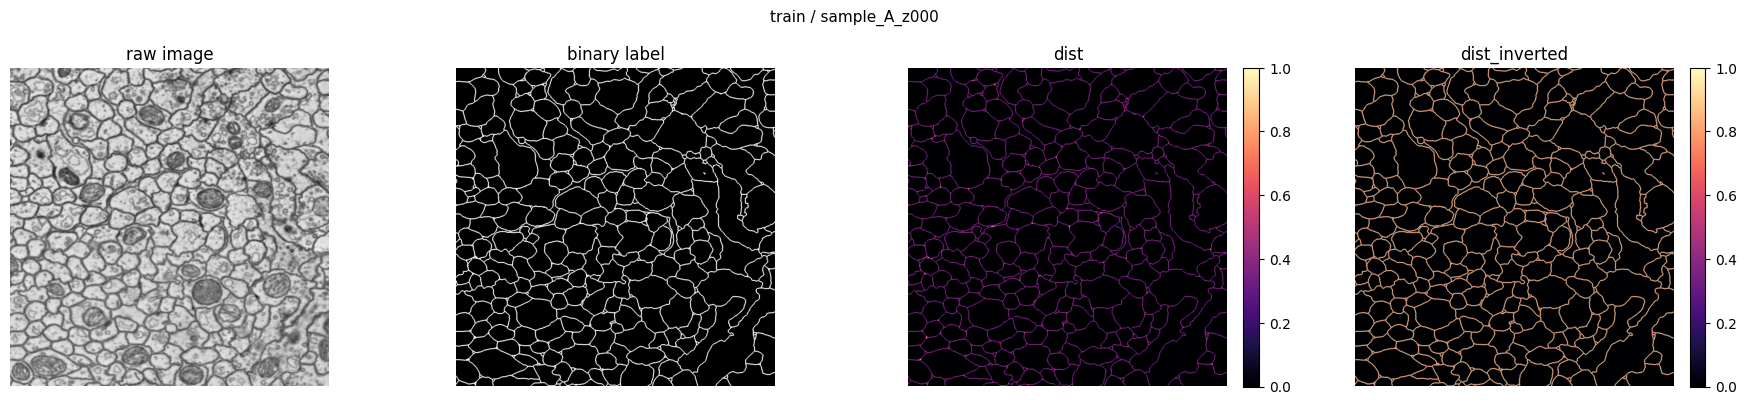

[train:sample_A_z000] binary(min/max)=(0.000, 1.000) dist(min/max)=(0.000, 1.000) dist_inv(min/max)=(0.000, 1.000)


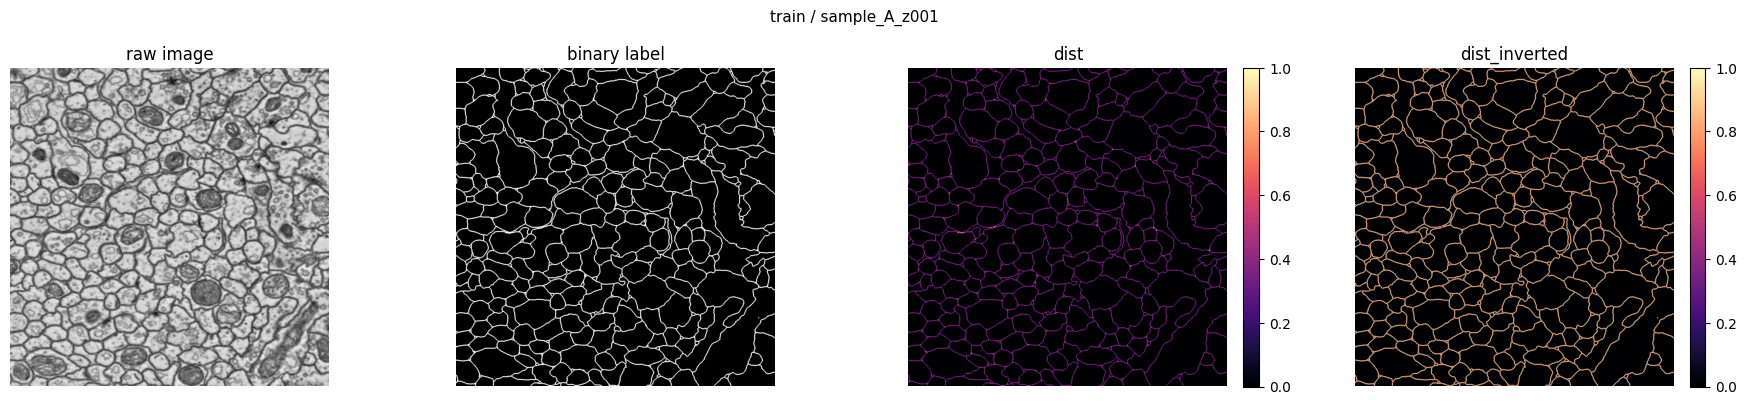

[train:sample_A_z001] binary(min/max)=(0.000, 1.000) dist(min/max)=(0.000, 1.000) dist_inv(min/max)=(0.000, 1.000)


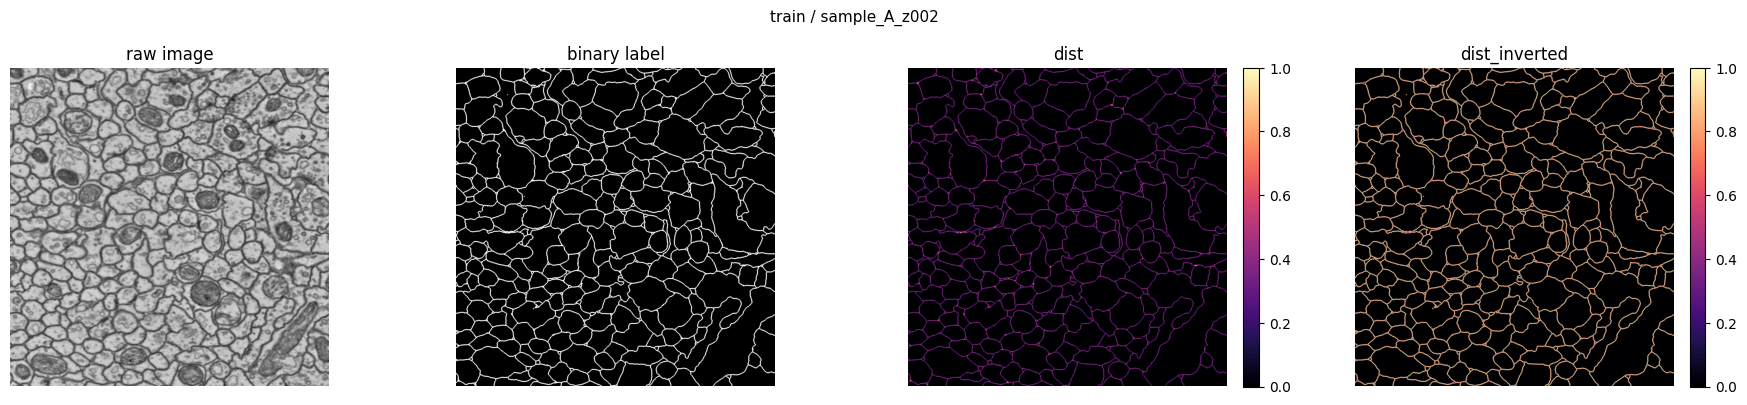

[train:sample_A_z002] binary(min/max)=(0.000, 1.000) dist(min/max)=(0.000, 1.000) dist_inv(min/max)=(0.000, 1.000)


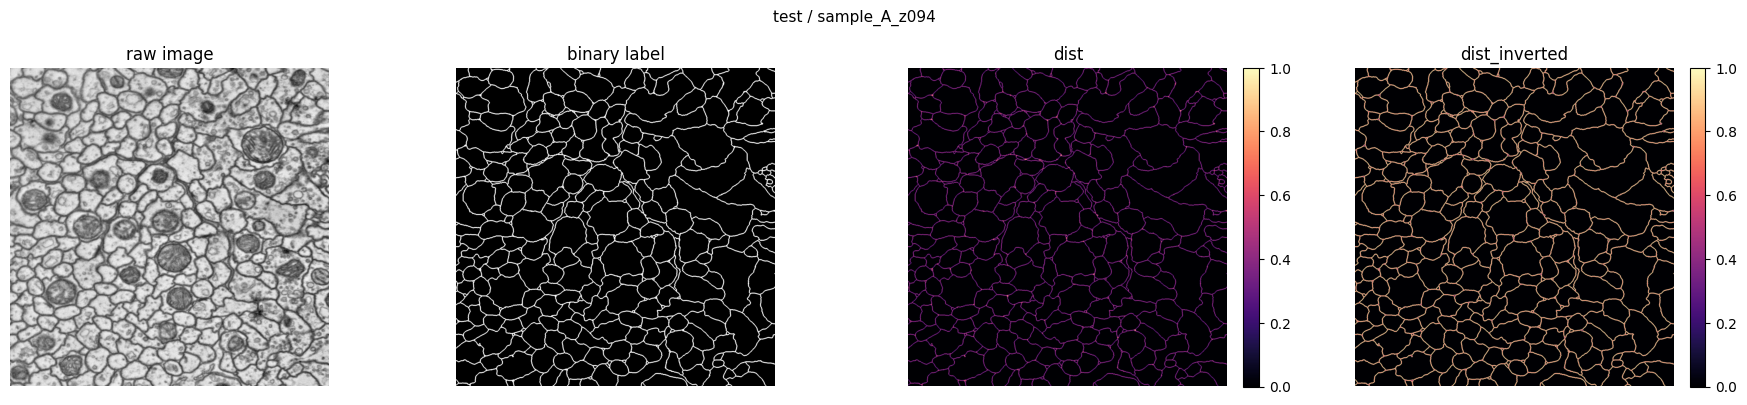

[test:sample_A_z094] binary(min/max)=(0.000, 1.000) dist(min/max)=(0.000, 1.000) dist_inv(min/max)=(0.000, 1.000)


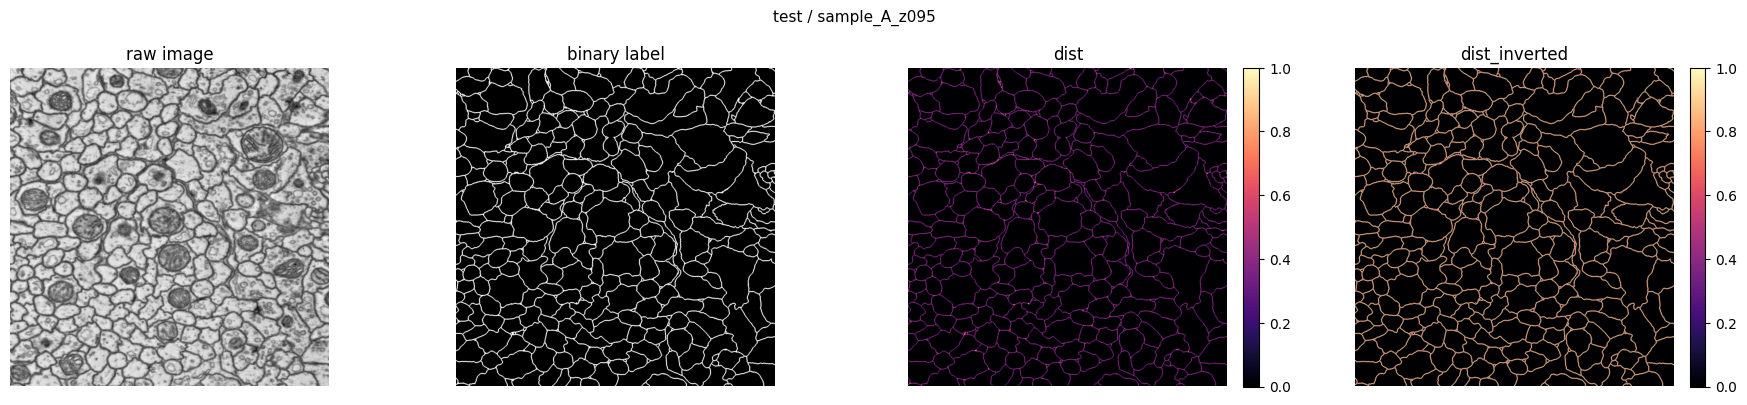

[test:sample_A_z095] binary(min/max)=(0.000, 1.000) dist(min/max)=(0.000, 1.000) dist_inv(min/max)=(0.000, 1.000)


In [8]:
import matplotlib.pyplot as plt


def visualize_split(split='train', max_samples=3):
    image_dir = BASE / split / 'images'
    label_dir = BASE / split / 'labels'
    dist_dir = BASE / split / 'labels_dist'
    inv_dir = BASE / split / 'labels_dist_inverted'

    image_files = sorted(image_dir.glob('*.npy'))[:max_samples]
    if not image_files:
        raise FileNotFoundError(f'No image files found in {image_dir}')

    for img_path in image_files:
        stem = img_path.stem
        raw = np.load(img_path)
        binary = np.load(label_dir / f'{stem}.npy')
        dist = np.load(dist_dir / f'{stem}_dist.npy')
        dist_inv = np.load(inv_dir / f'{stem}_dist_inverted.npy')

        fig, axes = plt.subplots(1, 4, figsize=(18, 4))
        fig.suptitle(f'{split} / {stem}', fontsize=11)

        axes[0].set_title('raw image')
        axes[0].imshow(raw, cmap='gray')
        axes[0].axis('off')

        axes[1].set_title('binary label')
        axes[1].imshow(binary, cmap='gray', vmin=0, vmax=1)
        axes[1].axis('off')

        axes[2].set_title('dist')
        im2 = axes[2].imshow(dist, cmap='magma', vmin=0, vmax=1)
        axes[2].axis('off')
        plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

        axes[3].set_title('dist_inverted')
        im3 = axes[3].imshow(dist_inv, cmap='magma', vmin=0, vmax=1)
        axes[3].axis('off')
        plt.colorbar(im3, ax=axes[3], fraction=0.046, pad=0.04)

        plt.tight_layout()
        plt.show()

        print(
            f'[{split}:{stem}] '
            f'binary(min/max)=({float(binary.min()):.3f}, {float(binary.max()):.3f}) '
            f'dist(min/max)=({float(dist.min()):.3f}, {float(dist.max()):.3f}) '
            f'dist_inv(min/max)=({float(dist_inv.min()):.3f}, {float(dist_inv.max()):.3f})'
        )


visualize_split('train', max_samples=3)
visualize_split('test', max_samples=2)

## Dataloader Smoke Test (`GetDataset_CREMI.py`)

Load one sample for each `label_mode` and confirm tensor shape/range.

In [9]:
from types import SimpleNamespace
from data_loader.GetDataset_CREMI import getdataset_cremi

args = SimpleNamespace(resize=[256, 256])
expected_train = 83
expected_test = 42

for mode in ['binary', 'dist', 'dist_inverted']:
    ds_train = getdataset_cremi(args=args, train_root='data/CREMI', mode='train', label_mode=mode)
    ds_test = getdataset_cremi(args=args, train_root='data/CREMI', mode='test', label_mode=mode)

    assert len(ds_train) == expected_train, f'train count mismatch: {len(ds_train)} != {expected_train}'
    assert len(ds_test) == expected_test, f'test count mismatch: {len(ds_test)} != {expected_test}'

    x_train, y_train = ds_train[0]
    x_test, y_test, name_test = ds_test[0]

    print(f'[{mode}] train_len={len(ds_train)}, test_len={len(ds_test)}')
    print(
        f'  train sample: x={tuple(x_train.shape)} {x_train.dtype} '
        f'y={tuple(y_train.shape)} {y_train.dtype} '
        f'y[min,max]=({float(y_train.min()):.4f}, {float(y_train.max()):.4f})'
    )
    print(
        f'  test sample : x={tuple(x_test.shape)} {x_test.dtype} '
        f'y={tuple(y_test.shape)} {y_test.dtype} '
        f'name={name_test}'
    )


[binary] train_len=94, test_len=31
  train sample: x=(3, 256, 256) torch.float32 y=(1, 256, 256) torch.float32 y[min,max]=(0.0000, 1.0000)
  test sample : x=(3, 256, 256) torch.float32 y=(1, 256, 256) torch.float32 name=sample_A_z094
[dist] train_len=94, test_len=31
  train sample: x=(3, 256, 256) torch.float32 y=(1, 256, 256) torch.float32 y[min,max]=(0.0000, 0.8825)
  test sample : x=(3, 256, 256) torch.float32 y=(1, 256, 256) torch.float32 name=sample_A_z094
[dist_inverted] train_len=94, test_len=31
  train sample: x=(3, 256, 256) torch.float32 y=(1, 256, 256) torch.float32 y[min,max]=(0.0000, 0.9993)
  test sample : x=(3, 256, 256) torch.float32 y=(1, 256, 256) torch.float32 name=sample_A_z094
